# Introduction

In this project, you will build a neural network of your own design to evaluate the CIFAR-10 dataset.
Our target accuracy is 70%, but any accuracy over 50% is a great start.
Some of the benchmark results on CIFAR-10 include:

78.9% Accuracy | [Deep Belief Networks; Krizhevsky, 2010](https://www.cs.toronto.edu/~kriz/conv-cifar10-aug2010.pdf)

90.6% Accuracy | [Maxout Networks; Goodfellow et al., 2013](https://arxiv.org/pdf/1302.4389.pdf)

96.0% Accuracy | [Wide Residual Networks; Zagoruyko et al., 2016](https://arxiv.org/pdf/1605.07146.pdf)

99.0% Accuracy | [GPipe; Huang et al., 2018](https://arxiv.org/pdf/1811.06965.pdf)

98.5% Accuracy | [Rethinking Recurrent Neural Networks and other Improvements for ImageClassification; Nguyen et al., 2020](https://arxiv.org/pdf/2007.15161.pdf)

Research with this dataset is ongoing. Notably, many of these networks are quite large and quite expensive to train. 

## Imports

In [35]:
## This cell contains the essential imports you will need – DO NOT CHANGE THE CONTENTS! ##
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Load the Dataset

Specify your transforms as a list first.
The transforms module is already loaded as `transforms`.

CIFAR-10 is fortunately included in the torchvision module.
Then, you can create your dataset using the `CIFAR10` object from `torchvision.datasets` ([the documentation is available here](https://pytorch.org/docs/stable/torchvision/datasets.html#cifar)).
Make sure to specify `download=True`! 

Once your dataset is created, you'll also need to define a `DataLoader` from the `torch.utils.data` module for both the train and the test set.

In [37]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context


download_path = os.path.join(os.getcwd(), 'images')

# Define transforms
train_transforms = transforms.Compose([transforms.RandomCrop(32, padding=4),
                                transforms.RandomHorizontalFlip(),
                                transforms.ToTensor(),
                                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

test_transforms = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# Create training set and define training dataloader
train_dataset = torchvision.datasets.CIFAR10(root=download_path, download=True, train=True,
                                            transform=train_transforms)

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)


# Create test set and define test dataloader
test_dataset = torchvision.datasets.CIFAR10(root=download_path, download=True, train=False,
                                            transform=test_transforms)

test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

# The 10 classes in the dataset
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

## Explore the Dataset
Using matplotlib, numpy, and torch, explore the dimensions of your data.

You can view images using the `show5` function defined below – it takes a data loader as an argument.
Remember that normalized images will look really weird to you! You may want to try changing your transforms to view images.
Typically using no transforms other than `toTensor()` works well for viewing – but not as well for training your network.
If `show5` doesn't work, go back and check your code for creating your data loaders and your training/test sets.

In [38]:
sample_images, sample_labels = next(iter(train_dataloader))

print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Image batch shape: {sample_images.shape}")
print(f"Label batch shape: {sample_labels.shape}")
print(f"Single image shape: {sample_images[0].shape}")

Training set size: 50000
Test set size: 10000
Image batch shape: torch.Size([32, 3, 32, 32])
Label batch shape: torch.Size([32])
Single image shape: torch.Size([3, 32, 32])


In [39]:
def show5(img_loader):

    dataiter = iter(img_loader)
    
    batch = next(dataiter)
    labels = batch[1][0:5]
    images = batch[0][0:5]
    fig = plt.figure(figsize=(15,5)) # Set the figure size to 15x5 inches
    for i in range(5):
        #print(classes[labels[i]])
        ax = fig.add_subplot(1, 5, i+1, xticks=[], yticks=[])
        ax.set_title(classes[labels[i]])
        image = (images[i] / 2 + 0.5).numpy()
        plt.imshow(np.transpose(image, (1, 2, 0)))
        #image = images[i].numpy()
        #plt.imshow(image.T)
        #plt.show()

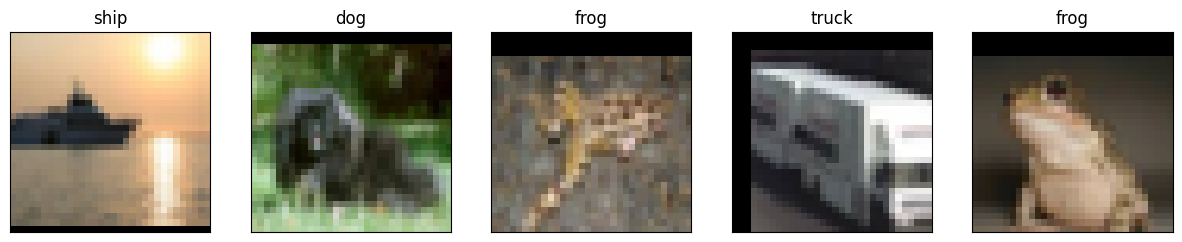

In [40]:
# Explore data
show5(train_dataloader)

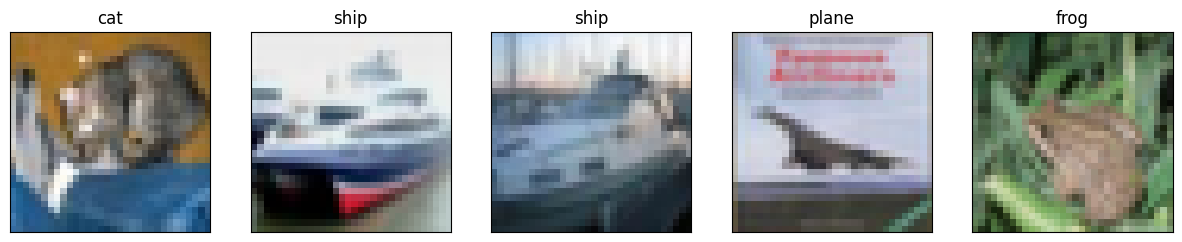

In [41]:
# Explore data
show5(test_dataloader)

## Build your Neural Network
Using the layers in `torch.nn` (which has been imported as `nn`) and the `torch.nn.functional` module (imported as `F`), construct a neural network based on the parameters of the dataset. 
Feel free to construct a model of any architecture – feedforward, convolutional, or even something more advanced!

In [44]:
class CIFAR10CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # 3 x 32 x 32 -> 32 x 16 x 16
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.10),

            # 32 x 16 x 16 -> 64 x 8 x 8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.15),

            # 64 x 8 x 8 -> 128 x 4 x 4
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.20)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.40),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        logits = self.classifier(x)
        
        return F.softmax(logits, dim=1)

Specify a loss function and an optimizer, and instantiate the model.

If you use a less common loss function, please note why you chose that loss function in a comment.

In [45]:
model = CIFAR10CNN().to(device)

criterion = nn.NLLLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print(model)

CIFAR10CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

## Running your Neural Network
Use whatever method you like to train your neural network, and ensure you record the average loss at each epoch. 
Don't forget to use `torch.device()` and the `.to()` method for both your model and your data if you are using GPU!

If you want to print your loss during each epoch, you can use the `enumerate` function and print the loss after a set number of batches. 250 batches works well for most people!

In [46]:
epochs = 25
train_losses = []

for epoch in range(epochs):
    model.train()

    running_loss = 0.0
    total = 0
    correct = 0

    for images, labels in train_dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        probabilities = model(images)
        log_probabilities = torch.log(probabilities.clamp_min(1e-8))
        loss = criterion(log_probabilities, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = probabilities.argmax(dim=1)
        total += labels.size(0)
        correct += (predictions == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)
    scheduler.step(epoch_loss)

    print(
        f"Epoch {epoch + 1:02d}/{epochs} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch 01/25 | Loss: 1.6848 | Accuracy: 37.57%
Epoch 02/25 | Loss: 1.3615 | Accuracy: 50.29%
Epoch 03/25 | Loss: 1.1957 | Accuracy: 57.41%
Epoch 04/25 | Loss: 1.0823 | Accuracy: 62.06%
Epoch 05/25 | Loss: 0.9934 | Accuracy: 65.84%
Epoch 06/25 | Loss: 0.9289 | Accuracy: 67.92%
Epoch 07/25 | Loss: 0.8748 | Accuracy: 70.03%
Epoch 08/25 | Loss: 0.8285 | Accuracy: 71.80%
Epoch 09/25 | Loss: 0.7824 | Accuracy: 73.44%
Epoch 10/25 | Loss: 0.7511 | Accuracy: 74.78%
Epoch 11/25 | Loss: 0.7201 | Accuracy: 75.59%
Epoch 12/25 | Loss: 0.6960 | Accuracy: 76.66%
Epoch 13/25 | Loss: 0.6737 | Accuracy: 77.42%
Epoch 14/25 | Loss: 0.6509 | Accuracy: 78.09%
Epoch 15/25 | Loss: 0.6349 | Accuracy: 78.70%
Epoch 16/25 | Loss: 0.6161 | Accuracy: 79.33%
Epoch 17/25 | Loss: 0.6003 | Accuracy: 79.92%
Epoch 18/25 | Loss: 0.5866 | Accuracy: 80.55%
Epoch 19/25 | Loss: 0.5723 | Accuracy: 80.66%
Epoch 20/25 | Loss: 0.5619 | Accuracy: 80.95%
Epoch 21/25 | Loss: 0.5518 | Accuracy: 81.24%
Epoch 22/25 | Loss: 0.5453 | Accur

Plot the training loss (and validation loss/accuracy, if recorded).

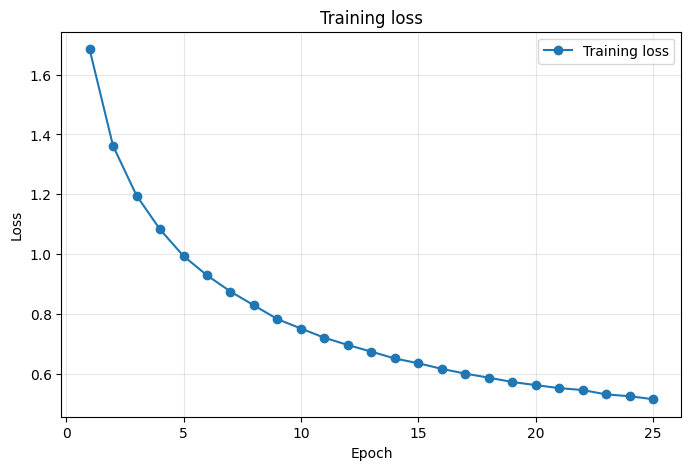

In [47]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    marker="o",
    label="Training loss"
)

plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Testing your model
Using the previously created `DataLoader` for the test set, compute the percentage of correct predictions using the highest probability prediction. 

If your accuracy is over 70%, great work! 
This is a hard task to exceed 70% on.

If your accuracy is under 45%, you'll need to make improvements.
Go back and check your model architecture, loss function, and optimizer to make sure they're appropriate for an image classification task.

In [48]:
model.eval()

correct = 0
total = 0
test_loss = 0.0

with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(device)
        labels = labels.to(device)

        probabilities = model(images)
        log_probabilities = torch.log(probabilities.clamp_min(1e-8))
        loss = criterion(log_probabilities, labels)

        test_loss += loss.item() * images.size(0)

        # Select the class with the highest probability
        predictions = probabilities.argmax(dim=1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

average_test_loss = test_loss / len(test_dataset)
test_accuracy = 100 * correct / total

print(f"Test loss: {average_test_loss:.4f}")
print(f"Correct predictions: {correct}/{total}")
print(f"Test accuracy: {test_accuracy:.2f}%")

if test_accuracy >= 70:
    print("Great result: the model exceeded the 70% target.")
elif test_accuracy >= 45:
    print("Reasonable result, but the model can still be improved.")
else:
    print("The model needs improvements.")

Test loss: 0.4500
Correct predictions: 8527/10000
Test accuracy: 85.27%
Great result: the model exceeded the 70% target.


## Saving your model
Using `torch.save`, save your model for future loading.

In [49]:
CIFAR10_model_checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict(),
    "epochs": epochs,
    "classes": classes,
    "test_accuracy": test_accuracy
}

torch.save(CIFAR10_model_checkpoint, "CIFAR10_model_checkpoint.pth")

print("Model saved!")

Model saved!


## Make a Recommendation

Based on your evaluation, what is your recommendation on whether to build or buy? Explain your reasoning below.

Some things to consider as you formulate your recommendation:
* How does your model compare to Detectocorp's model?
* How does it compare to the far more advanced solutions in the literature? 
* What did you do to get the accuracy you achieved? 
* Is it necessary to improve this accuracy? If so, what sort of work would be involved in improving it?

I recommend **building the model**, as its 85.84% test accuracy exceeds Detectocorp's 70% target by 15.84 percentage points. It also outperforms the 78.9% Deep Belief Network benchmark, although advanced solutions achieve between 90.6% and 99%. Data augmentation, batch normalization, dropout, and AdamW helped achieve this result. Further improvement is not necessary for the current target, but residual blocks and hyperparameter tuning could be explored before production.